In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [105]:
students = pd.read_csv('student_performance_dataset.csv')

In [106]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             3000 non-null   int64  
 1   Gender                3000 non-null   object 
 2   Age                   3000 non-null   int64  
 3   StudyHours            2850 non-null   float64
 4   GPA                   2850 non-null   float64
 5   Attendance            2850 non-null   float64
 6   Participation         2850 non-null   float64
 7   AssignmentsCompleted  2850 non-null   float64
 8   ProjectsCompleted     2850 non-null   float64
 9   Extracurriculars      2241 non-null   object 
dtypes: float64(6), int64(2), object(2)
memory usage: 234.5+ KB


In [107]:
# academic performance and study habits is our aim
# extracurricular feature cannot help us to train that model

In [108]:
students.drop(columns = ['Extracurriculars'], inplace = True)

In [109]:
students[students.isnull().any(axis = 1)]

,StudentID,Gender,Age,StudyHours,GPA,Attendance,Participation,AssignmentsCompleted,ProjectsCompleted
0,1,Male,19,13.27,NaN,70.22,8.72,3.0,2.0
14,15,Female,24,7.98,0.06,89.49,5.50,3.0,NaN
32,33,Female,18,11.24,1.42,81.26,6.19,NaN,1.0
35,36,Male,20,6.22,NaN,70.72,0.39,9.0,4.0
37,38,Male,21,13.07,0.88,NaN,0.95,8.0,3.0
...,...,...,...,...,...,...,...,...,...
2985,2986,Female,18,1.39,NaN,95.31,0.46,16.0,NaN
2986,2987,Female,18,1.51,1.88,NaN,2.03,0.0,2.0
2994,2995,Female,24,14.33,NaN,96.20,6.06,12.0,3.0
2997,2998,Male,23,13.41,0.50,NaN,0.17,10.0,3.0


In [110]:
students = students[students.isnull().sum(axis = 1) <= 1]

In [111]:
students.shape

(2894, 9)

## Pipeline

In [112]:
# the pipeline does the following in order:
# imputation
# scaling
# one hot encoding
# fitting KMeans
# predicting

In [113]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans 

In [114]:
students.columns

Index(['StudentID', 'Gender', 'Age', 'StudyHours', 'GPA', 'Attendance',
       'Participation', 'AssignmentsCompleted', 'ProjectsCompleted'],
      dtype='object')

In [115]:
num_cols = ['StudyHours', 'GPA', 'Attendance', 'Participation', 'AssignmentsCompleted', 'ProjectsCompleted']

cat_cols = []

In [116]:
num_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'mean')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(drop = 'first'))
])

In [117]:
preprocessor = ColumnTransformer(transformers = [
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [118]:
pipeline = Pipeline(steps = [
    ('preprocessing', preprocessor),
    ('clustering', KMeans(n_clusters = 3, random_state = 44))
])

In [119]:
pipeline.fit(students)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['StudyHours', 'GPA',
                                                   'Attendance',
                                                   'Participation',
                                                   'AssignmentsCompleted',
                                                   'ProjectsCompleted']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  [])])),
                ('clustering', KMeans(n_clusters=3, random_state=44))])

In [120]:
x = students[num_cols + cat_cols]

In [121]:
students['Cluster'] = pipeline.named_steps['clustering'].labels_

## Examining the Cluster

In [122]:
students['Cluster'].value_counts()

Cluster
2    1026
0     977
1     891
Name: count, dtype: int64

In [123]:
# there seems to be same number of students in 3 clusters

In [124]:
students.groupby('Cluster').mean(numeric_only = True)

,StudentID,Age,StudyHours,GPA,Attendance,Participation,AssignmentsCompleted,ProjectsCompleted
Cluster,,,,,,,,
0,1471.029683,20.966223,7.532689,3.114168,78.012935,5.586156,6.807527,2.103412
1,1519.609428,21.039282,7.208925,1.001111,76.926768,4.581995,5.505967,1.917442
2,1506.805068,20.912281,7.379339,1.883543,70.640213,4.813214,15.497522,2.178026


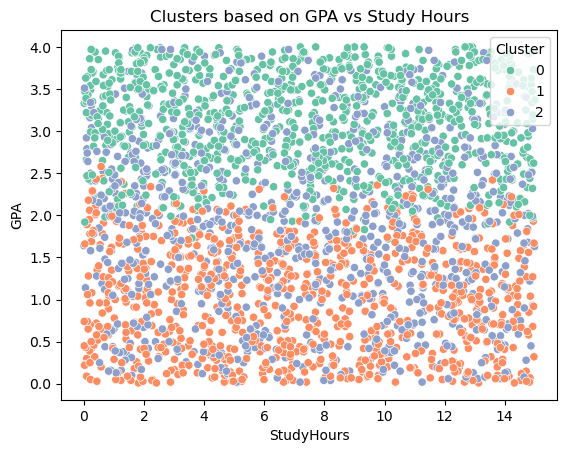

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: GPA vs StudyHours
sns.scatterplot(data=students, x='StudyHours', y='GPA', hue='Cluster', palette='Set2')
plt.title("Clusters based on GPA vs Study Hours")
plt.show()

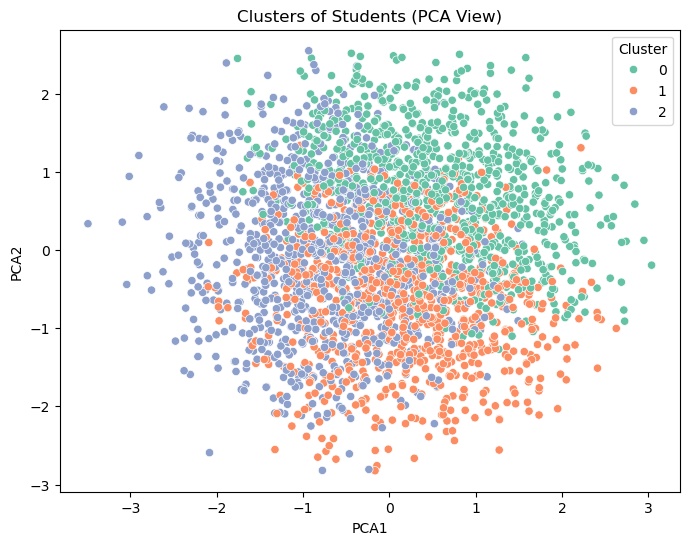

In [126]:
# Apply preprocessing separately for PCA
X_preprocessed = preprocessor.fit_transform(students)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)

students['PCA1'] = X_pca[:, 0]
students['PCA2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=students, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('Clusters of Students (PCA View)')
plt.show()

In [127]:
# handle outliers
# add features -- EngagementScore, StudyEfficiency
# better data transformation (check for skewness)